In [1]:
# Step 01 — Global configuration

from pathlib import Path

REPO_URL = "https://github.com/YutingLi0606/Idempotent-Continual-Learning.git"

ROOT = Path("/kaggle/working")
REPO = ROOT / "Idempotent-Continual-Learning"
OUT = ROOT / "ider_reproduction"
DATA_ROOT = ROOT / "data"

CHECKPOINT_OUT = OUT / "checkpoints"
RESUME_BUNDLE = ROOT / "IDER_RESUME_BUNDLE.zip"
RESUME_STATE = OUT / "resume_state.json"

OUT.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_OUT.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = {
    "cifar10_b200":   dict(dataset="seq-cifar10",  buffer=200,  tasks=5),
    "cifar10_b500":   dict(dataset="seq-cifar10",  buffer=500,  tasks=5),
    "cifar100_b500":  dict(dataset="seq-cifar100", buffer=500,  tasks=10),
    "cifar100_b2000": dict(dataset="seq-cifar100", buffer=2000, tasks=10),
    "tiny_b500":      dict(dataset="seq-tinyimg",  buffer=500,  tasks=10),
    "tiny_b4000":     dict(dataset="seq-tinyimg",  buffer=4000, tasks=10),
}

ACTIVE_EXPERIMENTS = list(EXPERIMENTS)
SEEDS = [0, 1, 2, 3, 4]

CLASS_BALANCE = True
DEVICE = "cuda:0"

# Multi-session mode:
# Each Kaggle session runs only this many NEW experiment/seed jobs.
# Completed jobs restored from a previous bundle are skipped automatically.
# Set to None if you want to try all remaining jobs in one session.
MAX_NEW_RUNS_PER_SESSION = 2

# If a previous IDER_RESUME_BUNDLE.zip is attached under /kaggle/input,
# restore it automatically before training.
AUTO_RESTORE_PREVIOUS_SESSION = True

print("Experiments:", ACTIVE_EXPERIMENTS)
print("Seeds:", SEEDS)
print("Total planned runs:", len(ACTIVE_EXPERIMENTS) * len(SEEDS))
print("New runs allowed this session:", MAX_NEW_RUNS_PER_SESSION)
print("Persistent checkpoint directory:", CHECKPOINT_OUT)
print("Resume bundle:", RESUME_BUNDLE)


Experiments: ['cifar10_b200', 'cifar10_b500', 'cifar100_b500', 'cifar100_b2000', 'tiny_b500', 'tiny_b4000']
Seeds: [0, 1, 2, 3, 4]
Total planned runs: 30
New runs allowed this session: 2
Persistent checkpoint directory: /kaggle/working/ider_reproduction/checkpoints
Resume bundle: /kaggle/working/IDER_RESUME_BUNDLE.zip


In [2]:
# Step 02 — Python / OS information

import sys, platform, os
print("Python:", sys.version)
print("OS:", platform.platform())
print("Working directory:", ROOT)
print("CPU count:", os.cpu_count())


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
OS: Linux-6.12.90+-x86_64-with-glibc2.35
Working directory: /kaggle/working
CPU count: 4


In [3]:
# Step 03 — GPU / CUDA information

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA runtime:", torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError("Enable a GPU accelerator in Kaggle before continuing.")

print("GPU:", torch.cuda.get_device_name(0))
props = torch.cuda.get_device_properties(0)
print("GPU memory (GB):", round(props.total_memory / 1024**3, 2))


PyTorch: 2.10.0+cu128
CUDA available: True
CUDA runtime: 12.8
GPU: Tesla T4
GPU memory (GB): 14.56


In [4]:
# Step 04 — torchvision information

import torchvision
print("torchvision:", torchvision.__version__)


torchvision: 0.25.0+cu128


In [5]:
# Step 05 — Reproducibility environment flags
# The authors' own seed handling remains authoritative inside main.py.
# These environment variables reduce avoidable nondeterminism without changing IDER's objective.

import os
os.environ["PYTHONHASHSEED"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTHONUNBUFFERED"] = "1"
print("Environment flags set.")


Environment flags set.


In [6]:
# Step 06 — Install auxiliary dependencies commonly absent from Kaggle.
# Do not downgrade Kaggle PyTorch automatically.

import importlib.util, subprocess, sys

REQ = {
    "mlflow": "mlflow",
    "setproctitle": "setproctitle",
    "onedrivedownloader": "onedrivedownloader",
    "torch_optimizer": "torch-optimizer",
    "randaugment": "randaugment",
    "easydict": "easydict",
    "timm": "timm",
}

missing = [pip for module, pip in REQ.items() if importlib.util.find_spec(module) is None]
print("Missing:", missing)

if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)


Missing: ['mlflow', 'setproctitle', 'onedrivedownloader', 'torch-optimizer', 'randaugment']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 592.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
# Step 07 — Clone official repository

import subprocess, shutil

if not REPO.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO)], check=True)
else:
    print("Using existing repository:", REPO)

commit = subprocess.check_output(
    ["git", "-C", str(REPO), "rev-parse", "HEAD"], text=True
).strip()

print("Commit:", commit)
(OUT / "repo_commit.txt").write_text(commit + "\n")


Cloning into '/kaggle/working/Idempotent-Continual-Learning'...


Commit: 18abadc8477c82fe384847493948acdc81004dc2


Updating files: 100% (3284/3284), done.


41

In [8]:
# Step 08 — Repository tree

for p in sorted(REPO.rglob("*")):
    if p.is_file() and ".git" not in p.parts:
        rel = p.relative_to(REPO)
        if len(rel.parts) <= 2:
            print(rel)


ASCEND/main.py
ASCEND/run_para_cifar10.sh
ASCEND/run_para_cifar100.sh
ASCEND/run_para_tinyimg.sh
README.md
backbone/EfficientNet.py
backbone/MNISTMLP.py
backbone/MNISTMLP_PNN.py
backbone/ResNet18.py
backbone/ResNet18_PNN.py
backbone/ResNet18_id2.py
backbone/__init__.py
datasets/__init__.py
datasets/gcil_cifar100.py
datasets/mnist_360.py
datasets/perm_mnist.py
datasets/rot_mnist.py
datasets/seq_cifar10.py
datasets/seq_cifar100.py
datasets/seq_mnist.py
datasets/seq_tinyimagenet.py
environment.yaml
img/Archi.jpg
img/Teaser.png
img/method.jpg
img/split_cifar10_200.png
img/split_cifar10_500.png
img/split_tinyimagenet_500.png
main.py
models/__init__.py
models/er.py
models/ider.py
run_para_cifar10.sh
run_para_cifar100.sh
run_para_tinyimg.sh
utils/__init__.py
utils/args.py
utils/augmentations.py
utils/batch_norm.py
utils/best_args.py
utils/buffer.py
utils/conf.py
utils/continual_training.py
utils/distributed.py
utils/loggers.py
utils/metrics.py
utils/mlflow_logger.py
utils/status.py
utils/trai

In [9]:
# Step 09 — Required-file integrity check

required = [
    "main.py",
    "models/ider.py",
    "models/er.py",
    "utils/buffer.py",
    "utils/best_args.py",
    "utils/training.py",
    "backbone/ResNet18_id2.py",
    "datasets/seq_cifar10.py",
    "datasets/seq_cifar100.py",
    "datasets/seq_tinyimagenet.py",
    "run_para_cifar10.sh",
    "run_para_cifar100.sh",
    "run_para_tinyimg.sh",
]

missing_files = [x for x in required if not (REPO / x).exists()]
print("Missing required files:", missing_files)
if missing_files:
    raise FileNotFoundError(missing_files)


Missing required files: []


In [10]:
# Step 10 — Hash important source files for provenance

import hashlib, pandas as pd

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

hash_rows = [{"file": f, "sha256": sha256(REPO/f)} for f in required]
hash_df = pd.DataFrame(hash_rows)
display(hash_df)
hash_df.to_csv(OUT/"source_hashes.csv", index=False)


,file,sha256
0,main.py,73b5985ccdad5f989db55135a7fb4658f476c8ab0eafbe...
1,models/ider.py,b452e6416c3e49a372494c04b56bc927a660ae5c719474...
2,models/er.py,d69b971ae1b4e8c2234564344fbd86caf507449c8fa938...
3,utils/buffer.py,efdf8593adff2097212dad49ff2875b4432d1e3b837cbb...
4,utils/best_args.py,5be59a02225ca40c03b32116b1bb82e0b3a3a51e754302...
5,utils/training.py,0acee44b3d44cc2469f688415578a873a07397b015f0ee...
6,backbone/ResNet18_id2.py,1a0e9a90f1262a4c91c1b55b9da41b33383897bd10fae6...
7,datasets/seq_cifar10.py,d83a88c29127dfee676ae904461d41b7e0dbf98989cbbd...
8,datasets/seq_cifar100.py,102db3d56806b7ad1fa91ee6f513729fce43648c95ced4...
9,datasets/seq_tinyimagenet.py,3f7e5bc371a8009a455f37aefdfaf6aa42af01e03df2a1...


In [11]:
# Step 11 — Utility for source inspection

def show_source(rel, start=1, end=None):
    path = REPO / rel
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    end = len(lines) if end is None else min(end, len(lines))
    print(f"\n### {rel} | lines {start}-{end}\n")
    for i in range(start-1, end):
        print(f"{i+1:4d}: {lines[i]}")


In [12]:
# Step 12 — Inspect IDER model implementation
show_source("models/ider.py")



### models/ider.py | lines 1-115

   1: import torch
   2: import copy
   3: from models.utils.continual_model import ContinualModel
   4: from utils.args import add_management_args, add_experiment_args, add_rehearsal_args, ArgumentParser
   5: from utils.buffer import Buffer
   6: import torch.nn.functional as F
   7: from utils.args import *
   8: 
   9: 
  10: 
  11: def add_parser(parser):
  12:     parser.add_argument('--weighta', type=float, help='Penalty weight for idempotence distillation.')
  13:     parser.add_argument('--weightb', type=float, help='Penalty weight for current idempotence distillation.')
  14:     parser.add_argument('--weightc', type=float, help='Penalty weight for er.')
  15:     parser.add_argument('--weightmask', type=float, help='Penalty weight for mask ratio.')
  16:     parser.add_argument("--class_balance", type=str2bool, default=True,
  17:                         help="If set, the memory buffer will be balanced by class")		
  18:     return parser
 

In [13]:
# Step 13 — Inspect replay buffer implementation
show_source("utils/buffer.py")



### utils/buffer.py | lines 1-309

   1: # Copyright 2022-present, Lorenzo Bonicelli, Pietro Buzzega, Matteo Boschini, Angelo Porrello, Simone Calderara.
   2: # All rights reserved.
   3: # This source code is licensed under the license found in the
   4: # LICENSE file in the root directory of this source tree.
   5: 
   6: import torch
   7: import torch.nn as nn
   8: import numpy as np
   9: from typing import Tuple
  10: from torchvision import transforms
  11: from copy import deepcopy
  12: 
  13: def icarl_replay(self, train_loader, val_set_split=0):
  14:     """
  15:     Merge the replay buffer with the current task data.
  16:     Optionally split the replay buffer into a validation set.
  17: 
  18:     :param self: the model instance
  19:     :param dataset: the dataset
  20:     :param val_set_split: the fraction of the replay buffer to be used as validation set
  21:     """
  22:         
  23:     if self.task_id > 0:
  24:         buff_val_mask = torch.rand(len(se

In [14]:
# Step 14 — Inspect modified ResNet-18
show_source("backbone/ResNet18_id2.py")



### backbone/ResNet18_id2.py | lines 1-286

   1: # Copyright 2022-present, Lorenzo Bonicelli, Pietro Buzzega, Matteo Boschini, Angelo Porrello, Simone Calderara.
   2: # All rights reserved.
   3: # This source code is licensed under the license found in the
   4: # LICENSE file in the root directory of this source tree.
   5: 
   6: from typing import List
   7: 
   8: import torch
   9: import torch.nn as nn
  10: import torch.nn.functional as F
  11: from torch.nn.functional import avg_pool2d, relu
  12: 
  13: from backbone import MammothBackbone
  14: 
  15: class Classifier(torch.nn.Module):
  16:     def __init__(self,
  17:                  feat_dim,
  18:                  nb_cls,
  19:                  cos_temp):
  20:         super(Classifier, self).__init__()
  21: 
  22:         fc = torch.nn.Linear(feat_dim, nb_cls)        
  23:         self.weight = torch.nn.Parameter(fc.weight.t(), requires_grad=True)
  24:         self.bias = torch.nn.Parameter(fc.bias, requires_grad

In [15]:
# Step 15 — Inspect training loop
show_source("utils/training.py")



### utils/training.py | lines 1-367

   1: # Copyright 2022-present, Lorenzo Bonicelli, Pietro Buzzega, Matteo Boschini, Angelo Porrello, Simone Calderara.
   2: # All rights reserved.
   3: # This source code is licensed under the license found in the
   4: # LICENSE file in the root directory of this source tree.
   5: import csv
   6: import math
   7: import sys
   8: from argparse import Namespace
   9: from typing import Tuple
  10: import torch
  11: from datasets import get_dataset
  12: from datasets.utils.continual_dataset import ContinualDataset
  13: from models.utils.continual_model import ContinualModel
  14: from typing import Tuple, List
  15: from utils.loggers import *
  16: from utils.mlflow_logger import MLFlowLogger
  17: from utils.status import ProgressBar
  18: import torch.nn.functional as F
  19: import utils.metrics
  20: 
  21: 
  22: def evaluate_ece(model: ContinualModel, dataset: ContinualDataset, last=False) -> Tuple[List[float], List[float], float, flo

In [16]:
# Step 16 — Inspect best hyperparameters
show_source("utils/best_args.py")



### utils/best_args.py | lines 1-1146

   1: # Copyright 2022-present, Lorenzo Bonicelli, Pietro Buzzega, Matteo Boschini, Angelo Porrello, Simone Calderara.
   2: # All rights reserved.
   3: # This source code is licensed under the license found in the
   4: # LICENSE file in the root directory of this source tree.
   5: 
   6: best_args = {
   7:     'perm-mnist': {
   8:         'sgd': {-1: {'lr': 0.2, 'batch_size': 128, 'n_epochs': 1}},
   9:         'ewc_on': {-1: {'lr': 0.1,
  10:                         'e_lambda': 0.7,
  11:                         'gamma': 1.0,
  12:                         'batch_size': 128,
  13:                         'n_epochs': 1}},
  14:         'si': {-1: {'lr': 0.1,
  15:                     'c': 0.5,
  16:                     'xi': 1.0,
  17:                     'batch_size': 128,
  18:                     'n_epochs': 1}},
  19:         'er': {200: {'lr': 0.2,
  20:                      'minibatch_size': 128,
  21:                      'batch_size'

In [17]:
# Step 17 — Inspect CIFAR-10 dataset/task pipeline
show_source("datasets/seq_cifar10.py")



### datasets/seq_cifar10.py | lines 1-142

   1: # Copyright 2022-present, Lorenzo Bonicelli, Pietro Buzzega, Matteo Boschini, Angelo Porrello, Simone Calderara.
   2: # All rights reserved.
   3: # This source code is licensed under the license found in the
   4: # LICENSE file in the root directory of this source tree.
   5: 
   6: from typing import Tuple
   7: 
   8: import torch.nn.functional as F
   9: import torchvision.transforms as transforms
  10: from backbone.ResNet18 import resnet18
  11: from PIL import Image
  12: from torchvision.datasets import CIFAR10
  13: from backbone.ResNet18_id2 import resnet18_id2
  14: from datasets.seq_tinyimagenet import base_path
  15: from datasets.transforms.denormalization import DeNormalize
  16: from datasets.utils.continual_dataset import (ContinualDataset,
  17:                                               store_masked_loaders)
  18: from datasets.utils.validation import get_train_val
  19: 
  20: 
  21: class TCIFAR10(CIFAR10):
  2

In [18]:
# Step 18 — Inspect CIFAR-100 dataset/task pipeline
show_source("datasets/seq_cifar100.py")



### datasets/seq_cifar100.py | lines 1-160

   1: # Copyright 2022-present, Lorenzo Bonicelli, Pietro Buzzega, Matteo Boschini, Angelo Porrello, Simone Calderara.
   2: # All rights reserved.
   3: # This source code is licensed under the license found in the
   4: # LICENSE file in the root directory of this source tree.
   5: 
   6: from typing import Tuple
   7: 
   8: import torch.nn.functional as F
   9: import torch.optim
  10: import torchvision.transforms as transforms
  11: from backbone.ResNet18 import resnet18
  12: from backbone.ResNet18_id2 import resnet18_id2
  13: from PIL import Image
  14: from torchvision.datasets import CIFAR100
  15: import torch.nn as nn
  16: from datasets.transforms.denormalization import DeNormalize
  17: from datasets.utils.continual_dataset import (ContinualDataset,
  18:                                               store_masked_loaders,
  19:                                               get_first_train_loader,
  20:                        

In [19]:
# Step 19 — TinyImageNet pipeline audit (concise)

from pathlib import Path
import ast

tiny_path = REPO / "datasets/seq_tinyimagenet.py"
tiny_src = tiny_path.read_text(encoding="utf-8", errors="replace")
tiny_tree = ast.parse(tiny_src)

# Find the continual-learning dataset class.
tiny_cls = next(
    node for node in tiny_tree.body
    if isinstance(node, ast.ClassDef) and node.name == "SequentialTinyImagenet"
)

# Evaluate simple class constants in source order.
env = {}

def _eval_simple(node):
    if isinstance(node, ast.Constant):
        return node.value
    if isinstance(node, ast.Name) and node.id in env:
        return env[node.id]
    if isinstance(node, ast.BinOp) and isinstance(node.op, ast.FloorDiv):
        return _eval_simple(node.left) // _eval_simple(node.right)
    return None

for stmt in tiny_cls.body:
    if isinstance(stmt, ast.Assign) and len(stmt.targets) == 1 and isinstance(stmt.targets[0], ast.Name):
        value = _eval_simple(stmt.value)
        if value is not None:
            env[stmt.targets[0].id] = value

# Read simple constant-return methods.
def _constant_return(method_name):
    fn = next(
        (n for n in tiny_cls.body if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef)) and n.name == method_name),
        None
    )
    if fn is None:
        return None
    for stmt in ast.walk(fn):
        if isinstance(stmt, ast.Return) and isinstance(stmt.value, ast.Constant):
            return stmt.value.value
    return None

default_epochs = _constant_return("get_epochs")
batch_size = _constant_return("get_batch_size")

print("TinyImageNet source:", tiny_path)
print("-" * 68)
print(f"Dataset name        : {env.get('NAME')}")
print(f"Setting             : {env.get('SETTING')}")
print(f"Total classes       : {env.get('N_CLASSES')}")
print(f"Tasks               : {env.get('N_TASKS')}")
print(f"Classes / task      : {env.get('N_CLASSES_PER_TASK')}")
print(f"Dataset default epoch: {default_epochs}")
print(f"Default batch size  : {batch_size}")
print(f"IDER backbone hook  : {'resnet18_id2' if 'resnet18_id2' in tiny_src else 'NOT FOUND'}")
print(f"Replay transform    : {'get_transform' if 'def get_transform' in tiny_src else 'NOT FOUND'}")
print(f"Auto-download code  : {'present' if 'onedrivedownloader' in tiny_src else 'not found'}")

# Show only the scheduler definitions instead of dumping the full ~180-line file.
scheduler_lines = [
    f"{i:03d}: {line.strip()}"
    for i, line in enumerate(tiny_src.splitlines(), start=1)
    if "MultiStepLR" in line or "args.n_epochs==50" in line
]

print("\nScheduler logic:")
for line in scheduler_lines:
    print(" ", line)

# Sanity checks for the official Split TinyImageNet setup.
assert env.get("NAME") == "seq-tinyimg"
assert env.get("SETTING") == "class-il"
assert env.get("N_TASKS") == 10
assert env.get("N_CLASSES") == 200
assert env.get("N_CLASSES_PER_TASK") == 20
assert batch_size == 32

print("\n[OK] TinyImageNet continual-learning pipeline passed structural checks.")


TinyImageNet source: /kaggle/working/Idempotent-Continual-Learning/datasets/seq_tinyimagenet.py
--------------------------------------------------------------------
Dataset name        : seq-tinyimg
Setting             : class-il
Total classes       : 200
Tasks               : 10
Classes / task      : 20
Dataset default epoch: 100
Default batch size  : 32
IDER backbone hook  : resnet18_id2
Replay transform    : get_transform
Auto-download code  : present

Scheduler logic:
  190: if  args.n_epochs==50:
  192: scheduler = torch.optim.lr_scheduler.MultiStepLR(model.opt, [35, 45], gamma=0.1, verbose=False)
  195: scheduler = torch.optim.lr_scheduler.MultiStepLR(model.opt, [35, 60, 75], gamma=0.1, verbose=False)

[OK] TinyImageNet continual-learning pipeline passed structural checks.


In [20]:
# Step 20 — Inspect authors' CIFAR-10 run script
show_source("run_para_cifar10.sh")



### run_para_cifar10.sh | lines 1-11

   1: for N_TASKS in  5
   2: do
   3:     for SEED in 0 1 2 3 4
   4:     do
   5:  
   6:     #python main.py --model="er" --load_best_args --savecheckpoint=True --dataset="seq-cifar10" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=500 --run_name="er seed $SEED $N_TASKS tasks" --experiment_name="try"
   7:     python main.py --model="ider" --load_best_args --savecheckpoint=True  --class_balance=True  --dataset="seq-cifar10" --device="cuda:6" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=200 --run_name=" er+id seed $SEED $N_TASKS tasks" --experiment_name="idempotent/cifar10/buffer200"
   8:     python main.py --model="ider" --load_best_args --savecheckpoint=True  --class_balance=True  --dataset="seq-cifar10" --device="cuda:6" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=500 --run_name=" er+id seed $SEED $N_TASKS tasks" --experiment_name="idempotent/cifar10/buffer500"
   9: 
  10:     done
  11: done


In [21]:
# Step 21 — Inspect authors' CIFAR-100 run script
show_source("run_para_cifar100.sh")



### run_para_cifar100.sh | lines 1-9

   1: for N_TASKS in  10
   2: do
   3:     for SEED in 0 1 2 3 4
   4:     do
   5:     #python main.py --model="er" --load_best_args --dataset="seq-cifar100" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=500 --run_name="er seed $SEED $N_TASKS tasks" --experiment_name="er/cifar100/buffer500"
   6:     python main.py --model="ider" --load_best_args --savecheckpoint=True  --class_balance=True  --dataset="seq-cifar100" --device="cuda:7" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=500 --run_name=" er+id seed $SEED $N_TASKS tasks" --experiment_name="idempotent/cifar100/buffer500"
   7:     #python main.py --model="ider" --load_best_args --savecheckpoint=True  --class_balance=True  --dataset="seq-cifar100" --device="cuda:7" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=2000 --run_name=" er+id  seed $SEED $N_TASKS tasks" --experiment_name="idempotent/cifar100/buffer2000"
   8:     done
   9: done


In [22]:
# Step 22 — Inspect authors' TinyImageNet run script
show_source("run_para_tinyimg.sh")



### run_para_tinyimg.sh | lines 1-11

   1: for N_TASKS in  10
   2: do
   3:     for SEED in 0 1 2 3 4
   4:     do
   5: 
   6:  
   7:     #python main.py --model="er" --load_best_args --dataset="seq-tinyimg" --device="cuda:1" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=500 --run_name="er seed $SEED $N_TASKS tasks" --experiment_name="try"
   8:     python main.py --model="ider" --load_best_args --savecheckpoint=True  --class_balance=True  --dataset="seq-tinyimg" --device="cuda:4" --seed=$SEED --n_tasks=$N_TASKS --buffer_size=4000 --run_name=" er+id seed $SEED $N_TASKS tasks" --experiment_name="idempotent/tinyimg/buffer4000"
   9: 
  10:     done
  11: done


In [23]:
# Step 23 — Import official best_args.py

import importlib.util

spec = importlib.util.spec_from_file_location("ider_best_args", REPO/"utils/best_args.py")
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
BEST_ARGS = mod.best_args

print("Loaded best_args from:", REPO/"utils/best_args.py")


Loaded best_args from: /kaggle/working/Idempotent-Continual-Learning/utils/best_args.py


In [24]:
# Step 24 — Print exact IDER hyperparameters for every requested setting

import pprint

for name in ACTIVE_EXPERIMENTS:
    e = EXPERIMENTS[name]
    print("\n", "="*80)
    print(name)
    pprint.pp(BEST_ARGS[e["dataset"]]["ider"][e["buffer"]])



cifar10_b200
{'lr': 0.03,
 'minibatch_size': 32,
 'weighta': 0.05,
 'weightb': 0.05,
 'weightc': 0.5,
 'weightmask': 1.0,
 'batch_size': 32,
 'n_epochs': 50}

cifar10_b500
{'lr': 0.03,
 'minibatch_size': 32,
 'weighta': 0.05,
 'weightb': 0.05,
 'weightc': 0.5,
 'weightmask': 1.0,
 'batch_size': 32,
 'n_epochs': 50}

cifar100_b500
{'lr': 0.03,
 'optim_mom': 0,
 'optim_wd': 0,
 'weighta': 0.5,
 'weightb': 0.4,
 'weightc': 0.5,
 'weightmask': 1.0}

cifar100_b2000
{'lr': 0.03,
 'optim_mom': 0,
 'optim_wd': 0,
 'weighta': 0.5,
 'weightb': 0.4,
 'weightc': 0.5,
 'weightmask': 1.0}

tiny_b500
{'lr': 0.03,
 'minibatch_size': 32,
 'weighta': 0.5,
 'weightb': 0.4,
 'weightc': 0.5,
 'weightmask': 1.0,
 'batch_size': 32,
 'n_epochs': 50}

tiny_b4000
{'lr': 0.03,
 'minibatch_size': 32,
 'weighta': 0.5,
 'weightb': 0.4,
 'weightc': 0.5,
 'weightmask': 1.0,
 'batch_size': 32,
 'n_epochs': 50}


In [25]:
# Step 25 — Build a compact hyperparameter audit table

rows = []
for name in ACTIVE_EXPERIMENTS:
    e = EXPERIMENTS[name]
    hp = dict(BEST_ARGS[e["dataset"]]["ider"][e["buffer"]])
    rows.append({
        "experiment": name,
        "dataset": e["dataset"],
        "buffer": e["buffer"],
        "tasks": e["tasks"],
        **hp,
    })

hp_df = pd.DataFrame(rows)
display(hp_df)
hp_df.to_csv(OUT/"official_best_args.csv", index=False)


,experiment,dataset,buffer,tasks,lr,minibatch_size,weighta,weightb,weightc,weightmask,batch_size,n_epochs,optim_mom,optim_wd
0,cifar10_b200,seq-cifar10,200,5,0.03,32.0,0.05,0.05,0.5,1.0,32.0,50.0,NaN,NaN
1,cifar10_b500,seq-cifar10,500,5,0.03,32.0,0.05,0.05,0.5,1.0,32.0,50.0,NaN,NaN
2,cifar100_b500,seq-cifar100,500,10,0.03,NaN,0.50,0.40,0.5,1.0,NaN,NaN,0.0,0.0
3,cifar100_b2000,seq-cifar100,2000,10,0.03,NaN,0.50,0.40,0.5,1.0,NaN,NaN,0.0,0.0
4,tiny_b500,seq-tinyimg,500,10,0.03,32.0,0.50,0.40,0.5,1.0,32.0,50.0,NaN,NaN
5,tiny_b4000,seq-tinyimg,4000,10,0.03,32.0,0.50,0.40,0.5,1.0,32.0,50.0,NaN,NaN


In [26]:
# Step 26 — Confirm class-balance mode used by this reproduction

print("CLASS_BALANCE =", CLASS_BALANCE)
assert CLASS_BALANCE is True


CLASS_BALANCE = True


In [27]:
# Step 27 — Locate reservoir/class-balance logic in buffer.py

text = (REPO/"utils/buffer.py").read_text(encoding="utf-8", errors="replace").splitlines()
keywords = ["reservoir", "class_balance", "num_seen_examples", "examples", "labels"]
for kw in keywords:
    print(f"\n--- matches for {kw!r} ---")
    for i, line in enumerate(text, 1):
        if kw.lower() in line.lower():
            print(f"{i:4d}: {line}")



--- matches for 'reservoir' ---
  67:     def __init__(self, buffer_size, device, num_seen_examples=0, blocked=False, n_tasks=None, mode='reservoir', class_balance=False):
  69:         assert mode in ['ring', 'reservoir']
  75:         else: print("Using standard reservoir buffer")
 103:     def reservoir(self, num_seen_examples: int, buffer_size: int) -> int:
 105:         Reservoir sampling algorithm.
 119:     def reservoir_balanced(self, num_seen_examples:int, buffer_size:int) -> int:
 173:     def get_index_reservoir(self, examples):
 175:         Get the insertion index of the given examples, using reservoir sampling
 182:                 idx = self.reservoir_balanced(self.num_seen_examples, self.buffer_size)
 184:                 idx = self.reservoir(self.num_seen_examples, self.buffer_size)
 192:         Adds the data to the memory buffer according to the reservoir strategy.
 211:                 index = self.reservoir_balanced(self.num_seen_examples, self.buffer_size)
 213: 

In [28]:
# Step 28 — Locate buffer calls inside IDER

text = (REPO/"models/ider.py").read_text(encoding="utf-8", errors="replace").splitlines()
for i, line in enumerate(text, 1):
    if "buffer" in line.lower():
        print(f"{i:4d}: {line}")


   5: from utils.buffer import Buffer
  17:                         help="If set, the memory buffer will be balanced by class")		
  34:         self.buffer = Buffer(self.args.buffer_size, self.device,class_balance = self.args.class_balance)
  66:         if not self.buffer.is_empty() and self.args.weightc !=0:
  67:             buf_inputs,  buf_labels,_,_,_ = self.buffer.get_data(
  80:         if not self.buffer.is_empty() and self.task>0 and self.args.weighta!=0:
  81:             buf_inputs,  buf_labels,_,_,_ = self.buffer.get_data(
  98:         self.buffer.add_data(examples=not_aug_inputs, labels=labels,logits=y_1_current.data, logits2=y_2_current.data,mask=y_0_current)


In [29]:
# Step 29 — Locate second-input / IDER-specific architecture operations

text = (REPO/"backbone/ResNet18_id2.py").read_text(encoding="utf-8", errors="replace").splitlines()
for i, line in enumerate(text, 1):
    low = line.lower()
    if any(k in low for k in ["linear", "leaky", "layer2", "layer3", "forward", "num_classes"]):
        print(f"{i:4d}: {line}")


  22:         fc = torch.nn.Linear(feat_dim, nb_cls)        
  39:     def forward(self, feature):
  82:     def forward(self, x: torch.Tensor) -> torch.Tensor:
  84:         Compute a forward pass.
 101:                  num_classes: int, nf: int) -> None:
 106:         :param num_classes: the number of output classes
 112:         self.num_classes = num_classes
 118:         self.layer2 = self._make_layer(block, nf * 2, num_blocks[1], stride=2)
 138:     def forward(self, x: torch.Tensor, returnt='out') -> torch.Tensor:
 140:         Compute a forward pass.
 150:         out = self.layer2(out)  # -> 128, 16, 16
 162:                  num_classes: int, nf: int,use_cos=False) -> None:
 167:         :param num_classes: the number of output classes
 173:         self.num_classes = num_classes
 177:         self.layer2 = self._make_layer(block, nf * 2, num_blocks[1], stride=2)
 178:         self.layer3 = self._make_layer(block, nf * 4, num_blocks[2], stride=2)
 180:         self.linear = 

In [30]:
# Step 30 — Compile-check repository Python files

import py_compile

failed = []
for p in REPO.rglob("*.py"):
    if ".git" in p.parts:
        continue
    try:
        py_compile.compile(str(p), doraise=True)
    except Exception as exc:
        failed.append((str(p.relative_to(REPO)), repr(exc)))

print("Compile failures:", len(failed))
for x in failed[:30]:
    print(x)


Compile failures: 0


In [31]:
# Step 31 — Back up files before compatibility patch

import shutil

backup = OUT/"source_backup"
backup.mkdir(exist_ok=True)

for rel in [
    "datasets/seq_cifar100.py",
    "datasets/seq_tinyimagenet.py",
    "utils/training.py",
    "utils/conf.py",
]:
    src = REPO/rel
    dst_bak = backup/rel.replace("/", "__")
    if not dst_bak.exists():
        shutil.copy2(src, dst_bak)

print("Backups:", sorted(p.name for p in backup.iterdir()))


Backups: ['datasets__seq_cifar100.py', 'datasets__seq_tinyimagenet.py', 'utils__conf.py', 'utils__training.py']


In [32]:
# Step 32 — Kaggle compatibility patches
# Only environment/path/API compatibility is changed here.
# IDER losses, replay policy, optimizer values, task splits and best_args are untouched.

# (A) PyTorch compatibility: remove deprecated/removed verbose=False from MultiStepLR.
for rel in ["datasets/seq_cifar100.py", "datasets/seq_tinyimagenet.py"]:
    p = REPO/rel
    s = p.read_text(encoding="utf-8")
    s2 = s.replace(", verbose=False)", ")")
    if s2 != s:
        p.write_text(s2, encoding="utf-8")
        print("Scheduler compatibility patch:", rel)
    else:
        print("Scheduler patch not needed:", rel)

# (B) Kaggle compatibility: the released repo points datasets to
#     /common_datasets2/CV/, which is an authors' server path.
#     Redirect only the dataset root to Kaggle's writable working directory.
conf = REPO/"utils/conf.py"
s = conf.read_text(encoding="utf-8")

old_path = "return '/common_datasets2/CV/'"
new_path = f"return {str(DATA_ROOT) + '/'!r}"

if old_path in s:
    s = s.replace(old_path, new_path, 1)
    conf.write_text(s, encoding="utf-8")
    print("Dataset root redirected to:", str(DATA_ROOT) + "/")
elif str(DATA_ROOT) in s:
    print("Dataset root already patched:", str(DATA_ROOT) + "/")
else:
    raise RuntimeError(
        "Could not locate the released repo dataset path in utils/conf.py. "
        "Inspect utils/conf.py before training."
    )


Scheduler compatibility patch: datasets/seq_cifar100.py
Scheduler compatibility patch: datasets/seq_tinyimagenet.py
Dataset root redirected to: /kaggle/working/data/


In [33]:
# Step 33 — Measurement-only patch: export task-end CIL/TIL snapshots to JSON.
# It does not modify model parameters, losses, optimizer, scheduler, data, or buffer.

p = REPO/"utils/training.py"
s = p.read_text(encoding="utf-8")

# The released file uses os.path later but relies on a wildcard import side effect.
# Make the dependency explicit for modern Python environments.
if "\nimport os\n" not in "\n" + s:
    insert_after = "import sys\n"
    if insert_after in s:
        s = s.replace(insert_after, insert_after + "import os\n", 1)


marker = "IDER_KAGGLE_METRIC_EXPORT_V2"

if marker not in s:
    anchor1 = "    results, results_mask_classes = [], []"
    if anchor1 not in s:
        raise RuntimeError("training.py anchor 1 not found; inspect repository before continuing.")
    repl1 = anchor1 + """
    # IDER_KAGGLE_METRIC_EXPORT_V2
    _ider_cil_snapshots = []
    _ider_til_snapshots = []
"""
    s = s.replace(anchor1, repl1, 1)

    anchor2 = """        results.append(accs[0])
        results_mask_classes.append(accs[1])"""
    if anchor2 not in s:
        raise RuntimeError("training.py anchor 2 not found; inspect repository before continuing.")
    repl2 = anchor2 + """
        # IDER_KAGGLE_METRIC_EXPORT_V2: measurement only
        _ider_cil_snapshots.append([float(v) for v in accs[0]])
        _ider_til_snapshots.append([float(v) for v in accs[1]])
        _export = os.environ.get("IDER_KAGGLE_EXPORT")
        if _export:
            import json as _json
            with open(_export, "w", encoding="utf-8") as _f:
                _json.dump({
                    "task_completed": int(t + 1),
                    "cil_snapshots": _ider_cil_snapshots,
                    "til_snapshots": _ider_til_snapshots,
                }, _f, indent=2)
"""
    s = s.replace(anchor2, repl2, 1)
    p.write_text(s, encoding="utf-8")
    print("Metric export patch applied.")
else:
    print("Metric export patch already present.")


Metric export patch applied.


In [34]:
# Step 34 — Re-compile patched files

for rel in [
    "datasets/seq_cifar100.py",
    "datasets/seq_tinyimagenet.py",
    "utils/training.py",
    "utils/conf.py",
]:
    py_compile.compile(str(REPO/rel), doraise=True)
    print("OK:", rel)


OK: datasets/seq_cifar100.py
OK: datasets/seq_tinyimagenet.py
OK: utils/training.py
OK: utils/conf.py


In [35]:
# Step 35 — CLI smoke test

import subprocess, sys

r = subprocess.run(
    [sys.executable, "main.py", "--help"],
    cwd=REPO,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)
print(r.stdout[:8000])
if r.returncode != 0:
    raise RuntimeError("Official repository CLI failed before training.")


usage: main.py [-h] --model {er,ider} [--load_best_args] [--seed SEED]
               [--notes NOTES] [--non_verbose {0,1}] [--disable_log {0,1}]
               [--validation {0,1}] [--ignore_other_metrics {0,1}] [--debug]
               [--experiment_name EXPERIMENT_NAME]
               [--parent_run_id PARENT_RUN_ID] [--run_name RUN_NAME]
               [--n_tasks N_TASKS]

mammoth

options:
  -h, --help            show this help message and exit
  --model {er,ider}     Model name.
  --load_best_args      Loads the best arguments for each method, dataset and
                        memory buffer.
  --seed SEED           The random seed.
  --notes NOTES         Notes for this run.
  --non_verbose {0,1}   Make progress bars non verbose
  --disable_log {0,1}   Enable csv logging
  --validation {0,1}    Test on the validation set
  --ignore_other_metrics {0,1}
                        disable additional metrics
  --debug               Run only a few forward steps per epoch
  --experiment_

In [36]:
# Step 36 — Create the 30-run manifest

manifest = []
for exp_name in ACTIVE_EXPERIMENTS:
    e = EXPERIMENTS[exp_name]
    for seed in SEEDS:
        manifest.append({
            "experiment": exp_name,
            "dataset": e["dataset"],
            "buffer": e["buffer"],
            "tasks": e["tasks"],
            "seed": seed,
        })

manifest_df = pd.DataFrame(manifest)
display(manifest_df)
manifest_df.to_csv(OUT/"run_manifest.csv", index=False)
print("Total:", len(manifest_df))


,experiment,dataset,buffer,tasks,seed
0,cifar10_b200,seq-cifar10,200,5,0
1,cifar10_b200,seq-cifar10,200,5,1
2,cifar10_b200,seq-cifar10,200,5,2
3,cifar10_b200,seq-cifar10,200,5,3
4,cifar10_b200,seq-cifar10,200,5,4
5,cifar10_b500,seq-cifar10,500,5,0
6,cifar10_b500,seq-cifar10,500,5,1
7,cifar10_b500,seq-cifar10,500,5,2
8,cifar10_b500,seq-cifar10,500,5,3
9,cifar10_b500,seq-cifar10,500,5,4


Total: 30


In [37]:
# Step 37 — Disk-space check

import shutil
usage = shutil.disk_usage(ROOT)
print("Total GB:", round(usage.total/1024**3, 2))
print("Used  GB:", round(usage.used/1024**3, 2))
print("Free  GB:", round(usage.free/1024**3, 2))


Total GB: 19.52
Used  GB: 4.69
Free  GB: 14.81


In [38]:
# Step 38 — Metric helper

import numpy as np

def metrics_from_snapshots(payload):
    cil = payload["cil_snapshots"]
    til = payload["til_snapshots"]
    if not cil:
        raise ValueError("No snapshots.")

    cil_faa = float(np.mean(cil[-1]))
    til_faa = float(np.mean(til[-1]))

    forgetting = []
    T = len(cil)
    for task_i in range(T-1):
        history = [cil[j][task_i] for j in range(task_i, T) if len(cil[j]) > task_i]
        forgetting.append(max(history) - cil[-1][task_i])

    return {
        "CIL_FAA": cil_faa,
        "TIL_FAA": til_faa,
        "Final_Forgetting": float(np.mean(forgetting)) if forgetting else 0.0,
    }


In [39]:
# Step 39 — Define persistent multi-session runner

import time
import json
import subprocess
import sys
import os
import shutil
import zipfile
from datetime import datetime, timezone


def checkpoint_candidates():
    """Find model checkpoint-like files created by the official repository."""
    found = []
    if not REPO.exists():
        return found

    for p in REPO.rglob("*"):
        if not p.is_file():
            continue
        low = p.name.lower()
        if (
            p.suffix.lower() in {".pth", ".pt", ".ckpt"}
            or low.endswith(".pth.tar")
        ):
            found.append(p)
    return sorted(found)


def checkpoint_fingerprint():
    """Fingerprint repo checkpoints so we can detect new/updated files per run."""
    fp = {}
    for p in checkpoint_candidates():
        try:
            st = p.stat()
            fp[str(p)] = (st.st_size, st.st_mtime_ns)
        except FileNotFoundError:
            pass
    return fp


def copy_changed_checkpoints(before_fp, exp_name, seed):
    """
    Copy every checkpoint that is new or changed during this run into a
    unique persistent directory under OUT/checkpoints/<experiment>/seed_<N>/.
    """
    run_ckpt_dir = CHECKPOINT_OUT / exp_name / f"seed_{seed}"
    run_ckpt_dir.mkdir(parents=True, exist_ok=True)

    copied = []
    after = checkpoint_fingerprint()

    for src_str, sig in after.items():
        if before_fp.get(src_str) == sig:
            continue

        src = Path(src_str)
        try:
            rel = src.relative_to(REPO)
            safe_name = str(rel).replace("/", "__").replace("\\", "__")
        except Exception:
            safe_name = src.name

        dst_ckpt = run_ckpt_dir / safe_name
        shutil.copy2(src, dst_ckpt)
        copied.append(str(dst_ckpt))

    manifest = {
        "experiment": exp_name,
        "seed": int(seed),
        "copied_checkpoint_count": len(copied),
        "checkpoints": copied,
        "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    (run_ckpt_dir / "checkpoint_manifest.json").write_text(
        json.dumps(manifest, indent=2),
        encoding="utf-8",
    )

    print(f"Persistent checkpoints copied for {exp_name} seed {seed}: {len(copied)}")
    for p in copied:
        print("  ", p)

    return copied


def completed_runs_from_disk():
    """Return all completed experiment/seed pairs already present in OUT."""
    completed = []
    for p in sorted(OUT.glob("*/seed_*/summary.json")):
        try:
            d = json.loads(p.read_text(encoding="utf-8"))
            completed.append({
                "experiment": d["experiment"],
                "seed": int(d["seed"]),
            })
        except Exception:
            pass
    return completed


def save_resume_state(last_completed=None):
    completed = completed_runs_from_disk()
    state = {
        "repo_commit": globals().get("commit"),
        "completed_runs": completed,
        "completed_count": len(completed),
        "total_planned_runs": len(ACTIVE_EXPERIMENTS) * len(SEEDS),
        "last_completed": last_completed,
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    RESUME_STATE.write_text(json.dumps(state, indent=2), encoding="utf-8")
    return state


def build_resume_bundle(last_completed=None):
    """
    Create a single ZIP containing:
      - summary.json files
      - task snapshot JSON files
      - training logs
      - persistent copied model checkpoints
      - source/config audit files
      - resume_state.json

    Save this ZIP as a Kaggle notebook output before ending the session.
    """
    state = save_resume_state(last_completed=last_completed)

    if RESUME_BUNDLE.exists():
        RESUME_BUNDLE.unlink()

    shutil.make_archive(
        str(RESUME_BUNDLE.with_suffix("")),
        "zip",
        root_dir=OUT,
    )

    print(
        f"Resume bundle updated: {RESUME_BUNDLE} | "
        f"completed {state['completed_count']}/{state['total_planned_runs']}"
    )
    return RESUME_BUNDLE


def restore_previous_session():
    """
    Auto-restore the newest attached IDER_RESUME_BUNDLE.zip from /kaggle/input.

    Kaggle workflow:
      1) At the end of a session, Save Version so the ZIP becomes notebook output.
      2) In the next session, add the previous output/dataset as Input.
      3) This function restores completed-run summaries and checkpoints.
    """
    if not AUTO_RESTORE_PREVIOUS_SESSION:
        print("Auto restore disabled.")
        return None

    input_root = Path("/kaggle/input")
    if not input_root.exists():
        print("No /kaggle/input directory; starting without prior resume bundle.")
        return None

    candidates = sorted(input_root.rglob("IDER_RESUME_BUNDLE.zip"))
    if not candidates:
        print("No previous IDER_RESUME_BUNDLE.zip found under /kaggle/input.")
        return None

    chosen = max(candidates, key=lambda p: p.stat().st_mtime_ns)
    print("Restoring previous session from:", chosen)

    with zipfile.ZipFile(chosen, "r") as zf:
        zf.extractall(OUT)

    restored = completed_runs_from_disk()
    print("Restored completed runs:", len(restored))
    for r in restored:
        print("  ", r["experiment"], "seed", r["seed"])

    return chosen


def run_one(exp_name, seed, force=False):
    e = EXPERIMENTS[exp_name]

    run_dir = OUT / exp_name / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    summary_file = run_dir / "summary.json"
    snapshots_file = run_dir / "task_snapshots.json"
    log_file = run_dir / "train.log"

    # This is the key multi-session behavior:
    # if a prior session completed this experiment/seed, do NOT retrain it.
    if summary_file.exists() and not force:
        print("SKIP completed:", exp_name, seed)
        return json.loads(summary_file.read_text(encoding="utf-8")), False

    cmd = [
        sys.executable, "main.py",
        "--model=ider",
        "--load_best_args",
        "--savecheckpoint=True",
        f"--class_balance={str(CLASS_BALANCE)}",
        f"--dataset={e['dataset']}",
        f"--device={DEVICE}",
        f"--seed={seed}",
        f"--n_tasks={e['tasks']}",
        f"--buffer_size={e['buffer']}",
        f"--run_name=kaggle_{exp_name}_seed{seed}",
        f"--experiment_name=kaggle_reproduction/{exp_name}",
        "--non_verbose=1",
        "--disable_log=1",
    ]

    env = os.environ.copy()
    env["IDER_KAGGLE_EXPORT"] = str(snapshots_file)
    env["PYTHONUNBUFFERED"] = "1"

    print("\n" + "=" * 100)
    print("EXPERIMENT:", exp_name, "| SEED:", seed)
    print(" ".join(cmd))
    print("=" * 100)

    # Snapshot repository checkpoints before the run.
    # Any new/modified checkpoint after the run will immediately be copied
    # to a unique persistent location under OUT/checkpoints.
    before_fp = checkpoint_fingerprint()

    start = time.time()
    with log_file.open("w", encoding="utf-8", buffering=1) as fout:
        proc = subprocess.Popen(
            cmd,
            cwd=REPO,
            env=env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )

        for line in proc.stdout:
            print(line, end="")
            fout.write(line)

        rc = proc.wait()

    elapsed = (time.time() - start) / 60

    # Even if a run fails, preserve any checkpoint the repo managed to write.
    copied_checkpoints = copy_changed_checkpoints(before_fp, exp_name, seed)

    if rc != 0:
        # Preserve logs/checkpoints/state before raising.
        save_resume_state(
            last_completed={
                "experiment": exp_name,
                "seed": int(seed),
                "status": "failed_or_interrupted",
            }
        )
        build_resume_bundle()

        tail = ""
        if log_file.exists():
            lines = log_file.read_text(
                encoding="utf-8",
                errors="replace",
            ).splitlines()
            tail = "\n".join(lines[-60:])

        raise RuntimeError(
            f"Run failed: {exp_name}, seed={seed}.\n"
            f"Log: {log_file}\n\n"
            f"Last log lines:\n{tail}"
        )

    if not snapshots_file.exists():
        build_resume_bundle()
        raise RuntimeError(f"No snapshot JSON: {snapshots_file}")

    payload = json.loads(snapshots_file.read_text(encoding="utf-8"))
    m = metrics_from_snapshots(payload)

    summary = {
        "experiment": exp_name,
        "dataset": e["dataset"],
        "buffer": e["buffer"],
        "tasks": e["tasks"],
        "seed": int(seed),
        "minutes": elapsed,
        "persistent_checkpoint_count": len(copied_checkpoints),
        **m,
    }

    summary_file.write_text(
        json.dumps(summary, indent=2),
        encoding="utf-8",
    )

    # Critical: update the portable resume bundle after EVERY completed run.
    build_resume_bundle(
        last_completed={
            "experiment": exp_name,
            "seed": int(seed),
            "status": "completed",
        }
    )

    return summary, True


In [40]:
# Step 40 — Final preflight before multi-session training

example = manifest_df.iloc[0].to_dict()
print("First planned run:", example)
print("Total planned runs:", len(manifest_df))

assert torch.cuda.is_available(), "GPU is not enabled."

conf_text = (REPO/"utils/conf.py").read_text(encoding="utf-8")
assert str(DATA_ROOT) in conf_text, "Kaggle dataset-root patch was not applied."

import inspect
runner_src = inspect.getsource(run_one)
assert "--non_verbose=1" in runner_src
assert "--disable_log=1" in runner_src
assert "--savecheckpoint=True" in runner_src

print("Preflight PASSED")
print("Dataset root:", str(DATA_ROOT) + "/")
print("Checkpoint output:", CHECKPOINT_OUT)
print("Resume bundle:", RESUME_BUNDLE)
print("MAX_NEW_RUNS_PER_SESSION:", MAX_NEW_RUNS_PER_SESSION)


First planned run: {'experiment': 'cifar10_b200', 'dataset': 'seq-cifar10', 'buffer': 200, 'tasks': 5, 'seed': 0}
Total planned runs: 30
Preflight PASSED
Dataset root: /kaggle/working/data/
Checkpoint output: /kaggle/working/ider_reproduction/checkpoints
Resume bundle: /kaggle/working/IDER_RESUME_BUNDLE.zip
MAX_NEW_RUNS_PER_SESSION: 2


In [41]:
# Step 41 — MULTI-SESSION TRAINING

# Restore results/checkpoints from a previous Kaggle session if the bundle
# was attached under /kaggle/input.
restore_previous_session()

all_results = []
new_runs_this_session = 0
stop_session = False

for exp_name in ACTIVE_EXPERIMENTS:
    if stop_session:
        break

    for seed in SEEDS:
        if (
            MAX_NEW_RUNS_PER_SESSION is not None
            and new_runs_this_session >= MAX_NEW_RUNS_PER_SESSION
        ):
            stop_session = True
            break

        result, was_new = run_one(
            exp_name,
            seed,
            force=False,
        )
        all_results.append(result)

        if was_new:
            new_runs_this_session += 1

print("\nNew runs completed this session:", new_runs_this_session)
print("Total completed runs now:", len(completed_runs_from_disk()))

# Make sure the latest portable bundle exists even if there were no new runs.
build_resume_bundle()

print("\nIMPORTANT FOR NEXT KAGGLE SESSION:")
print("1. Save Version / Save & Run All so IDER_RESUME_BUNDLE.zip is preserved as output.")
print("2. In the next notebook session, add the previous output as Kaggle Input.")
print("3. Run from the top. Completed experiment/seed jobs will be restored and skipped.")
print("4. If Kaggle stopped in the middle of one seed, only that unfinished seed restarts.")


No previous IDER_RESUME_BUNDLE.zip found under /kaggle/input.

EXPERIMENT: cifar10_b200 | SEED: 0
/usr/bin/python3 main.py --model=ider --load_best_args --savecheckpoint=True --class_balance=True --dataset=seq-cifar10 --device=cuda:0 --seed=0 --n_tasks=5 --buffer_size=200 --run_name=kaggle_cifar10_b200_seed0 --experiment_name=kaggle_reproduction/cifar10_b200 --non_verbose=1 --disable_log=1
ider
50
use changed model middle
backbone number of parameters = 11848906
Using class balanced buffer

  0%|          | 0.00/170M [00:00<?, ?B/s]
  0%|          | 32.8k/170M [00:00<30:30, 93.1kB/s]
  0%|          | 98.3k/170M [00:00<14:20, 198kB/s] 
  0%|          | 197k/170M [00:00<07:55, 358kB/s] 
  0%|          | 262k/170M [00:00<08:15, 344kB/s]
  0%|          | 328k/170M [00:01<08:26, 336kB/s]
  0%|          | 393k/170M [00:01<08:54, 318kB/s]
  0%|          | 459k/170M [00:01<08:51, 320kB/s]
  0%|          | 524k/170M [00:01<08:49, 321kB/s]
  0%|          | 590k/170M [00:01<08:49, 321kB/s]
  0%| 

In [42]:
# Step 42 — Reload all completed summaries from disk

summary_files = sorted(OUT.glob("*/seed_*/summary.json"))
records = [json.loads(p.read_text()) for p in summary_files]

results = pd.DataFrame(records)
if results.empty:
    raise RuntimeError("No completed runs found.")

results = results.sort_values(["experiment", "seed"]).reset_index(drop=True)
display(results)
results.to_csv(OUT/"per_seed_results.csv", index=False)


,experiment,dataset,buffer,tasks,seed,minutes,persistent_checkpoint_count,CIL_FAA,TIL_FAA,Final_Forgetting
0,cifar10_b200,seq-cifar10,200,5,0,280.705673,1,72.47,96.22,14.625
1,cifar10_b200,seq-cifar10,200,5,1,272.507657,1,71.86,95.39,15.275


In [43]:
# Step 43 — Verify seed completeness

completeness = (
    results.groupby("experiment")["seed"]
    .agg(["count", lambda s: sorted(s.tolist())])
    .reset_index()
)
completeness.columns = ["experiment", "n_runs", "seeds"]
display(completeness)


,experiment,n_runs,seeds
0,cifar10_b200,2,"[0, 1]"


In [44]:
# Step 44 — Five-seed mean ± std

agg = results.groupby("experiment").agg(
    n_runs=("seed", "count"),
    CIL_mean=("CIL_FAA", "mean"),
    CIL_std=("CIL_FAA", "std"),
    TIL_mean=("TIL_FAA", "mean"),
    TIL_std=("TIL_FAA", "std"),
    FF_mean=("Final_Forgetting", "mean"),
    FF_std=("Final_Forgetting", "std"),
    minutes_mean=("minutes", "mean"),
).reset_index()

display(agg)
agg.to_csv(OUT/"five_seed_aggregate.csv", index=False)


,experiment,n_runs,CIL_mean,CIL_std,TIL_mean,TIL_std,FF_mean,FF_std,minutes_mean
0,cifar10_b200,2,72.165,0.431335,95.805,0.586899,14.95,0.459619,276.606665


In [45]:
# Step 45 — Human-readable mean ± std table

pretty = agg.copy()
pretty["CIL FAA"] = pretty.apply(lambda r: f"{r.CIL_mean:.2f} ± {r.CIL_std:.2f}", axis=1)
pretty["TIL FAA (extra diagnostic)"] = pretty.apply(
    lambda r: f"{r.TIL_mean:.2f} ± {r.TIL_std:.2f}", axis=1
)
pretty["Final Forgetting"] = pretty.apply(
    lambda r: f"{r.FF_mean:.2f} ± {r.FF_std:.2f}", axis=1
)

display(
    pretty[
        [
            "experiment",
            "n_runs",
            "CIL FAA",
            "Final Forgetting",
            "TIL FAA (extra diagnostic)",
        ]
    ]
)

print("Note: TIL FAA is an additional diagnostic; it is not reported in the paper's main CIL tables.")


,experiment,n_runs,CIL FAA,Final Forgetting,TIL FAA (extra diagnostic)
0,cifar10_b200,2,72.16 ± 0.43,14.95 ± 0.46,95.81 ± 0.59


Note: TIL FAA is an additional diagnostic; it is not reported in the paper's main CIL tables.


In [46]:
# Step 46 — Paper reference values (Table 1 FAA + Table 7 FF)

# Exact ER+ID (Ours) values transcribed from the uploaded ICLR 2026 paper.
# Table 1: Final Average Accuracy (FAA) under Class-IL.
# Table 7: Final Forgetting (FF).
# TIL is intentionally NOT included because the paper's main tables do not report TIL FAA.

paper_reference = pd.DataFrame([
    ["cifar10_b200",    71.02, 1.98, 15.28, 2.41],
    ["cifar10_b500",    74.74, 0.42, 11.93, 0.49],
    ["cifar100_b500",   44.82, 0.85, 29.98, 2.52],
    ["cifar100_b2000",  56.59, 0.35, 17.46, 1.04],
    ["tiny_b500",       29.88, 1.15, 36.63, 3.37],
    ["tiny_b4000",      43.05, 1.40, 22.46, 1.86],
], columns=[
    "experiment",
    "Paper_FAA_mean",
    "Paper_FAA_std",
    "Paper_FF_mean",
    "Paper_FF_std",
])

display(paper_reference)
paper_reference.to_csv(OUT/"paper_reference_table1_table7.csv", index=False)


,experiment,Paper_FAA_mean,Paper_FAA_std,Paper_FF_mean,Paper_FF_std
0,cifar10_b200,71.02,1.98,15.28,2.41
1,cifar10_b500,74.74,0.42,11.93,0.49
2,cifar100_b500,44.82,0.85,29.98,2.52
3,cifar100_b2000,56.59,0.35,17.46,1.04
4,tiny_b500,29.88,1.15,36.63,3.37
5,tiny_b4000,43.05,1.40,22.46,1.86


In [47]:
# Step 47 — Compare Kaggle reproduction with paper-reported metrics

comparison = agg.merge(paper_reference, on="experiment", how="left")

comparison["FAA_delta_vs_paper"] = (
    comparison["CIL_mean"] - comparison["Paper_FAA_mean"]
)
comparison["FF_delta_vs_paper"] = (
    comparison["FF_mean"] - comparison["Paper_FF_mean"]
)

paper_comparison_cols = [
    "experiment",
    "n_runs",
    "CIL_mean",
    "CIL_std",
    "Paper_FAA_mean",
    "Paper_FAA_std",
    "FAA_delta_vs_paper",
    "FF_mean",
    "FF_std",
    "Paper_FF_mean",
    "Paper_FF_std",
    "FF_delta_vs_paper",
]

display(comparison[paper_comparison_cols])
comparison[paper_comparison_cols].to_csv(
    OUT/"paper_reference_comparison.csv",
    index=False,
)

print("TIL FAA is excluded from the paper comparison because the paper does not report it in the main CIL tables.")


,experiment,n_runs,CIL_mean,CIL_std,Paper_FAA_mean,Paper_FAA_std,FAA_delta_vs_paper,FF_mean,FF_std,Paper_FF_mean,Paper_FF_std,FF_delta_vs_paper
0,cifar10_b200,2,72.165,0.431335,71.02,1.98,1.145,14.95,0.459619,15.28,2.41,-0.33


TIL FAA is excluded from the paper comparison because the paper does not report it in the main CIL tables.


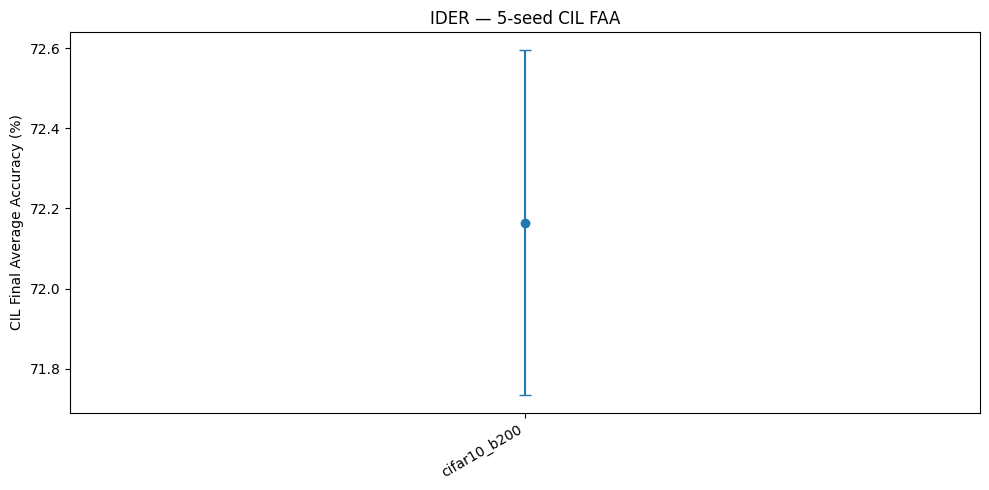

In [48]:
# Step 48 — CIL FAA plot

import matplotlib.pyplot as plt

plot_df = agg.sort_values("experiment")
plt.figure(figsize=(10, 5))
plt.errorbar(plot_df["experiment"], plot_df["CIL_mean"], yerr=plot_df["CIL_std"], fmt="o", capsize=4)
plt.xticks(rotation=30, ha="right")
plt.ylabel("CIL Final Average Accuracy (%)")
plt.title("IDER — 5-seed CIL FAA")
plt.tight_layout()
plt.savefig(OUT/"cil_faa.png", dpi=200, bbox_inches="tight")
plt.show()


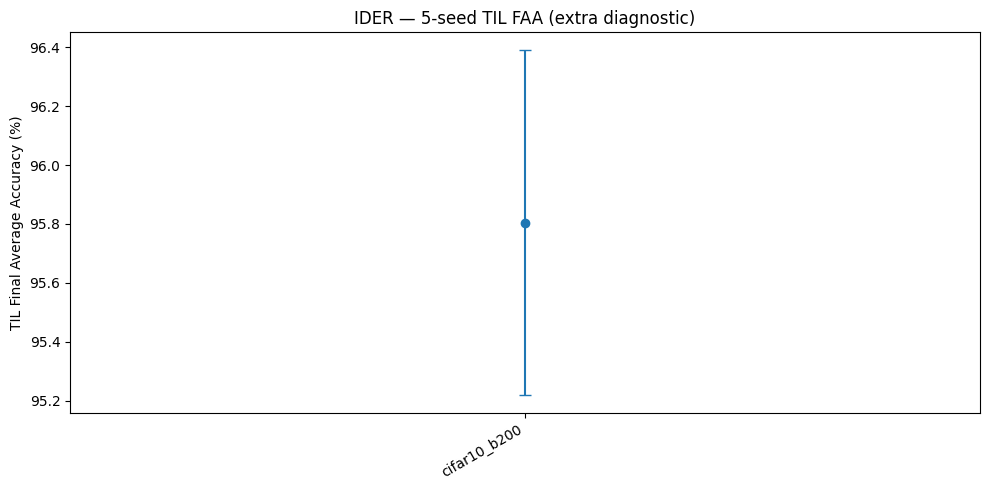

Diagnostic only: the paper's main Class-IL result tables report FAA/FF/ECE, not TIL FAA.


In [49]:
# Step 49 — TIL FAA diagnostic plot (not a paper Table 1 metric)

plt.figure(figsize=(10, 5))
plt.errorbar(
    plot_df["experiment"],
    plot_df["TIL_mean"],
    yerr=plot_df["TIL_std"],
    fmt="o",
    capsize=4,
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("TIL Final Average Accuracy (%)")
plt.title("IDER — 5-seed TIL FAA (extra diagnostic)")
plt.tight_layout()
plt.savefig(OUT/"til_faa_extra_diagnostic.png", dpi=200, bbox_inches="tight")
plt.show()

print("Diagnostic only: the paper's main Class-IL result tables report FAA/FF/ECE, not TIL FAA.")


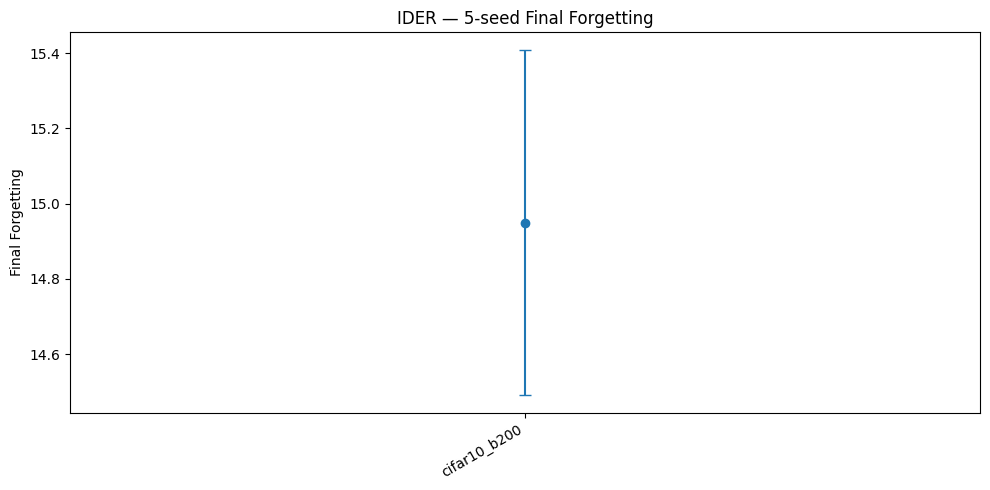

In [50]:
# Step 50 — Final Forgetting plot

plt.figure(figsize=(10, 5))
plt.errorbar(plot_df["experiment"], plot_df["FF_mean"], yerr=plot_df["FF_std"], fmt="o", capsize=4)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Final Forgetting")
plt.title("IDER — 5-seed Final Forgetting")
plt.tight_layout()
plt.savefig(OUT/"final_forgetting.png", dpi=200, bbox_inches="tight")
plt.show()


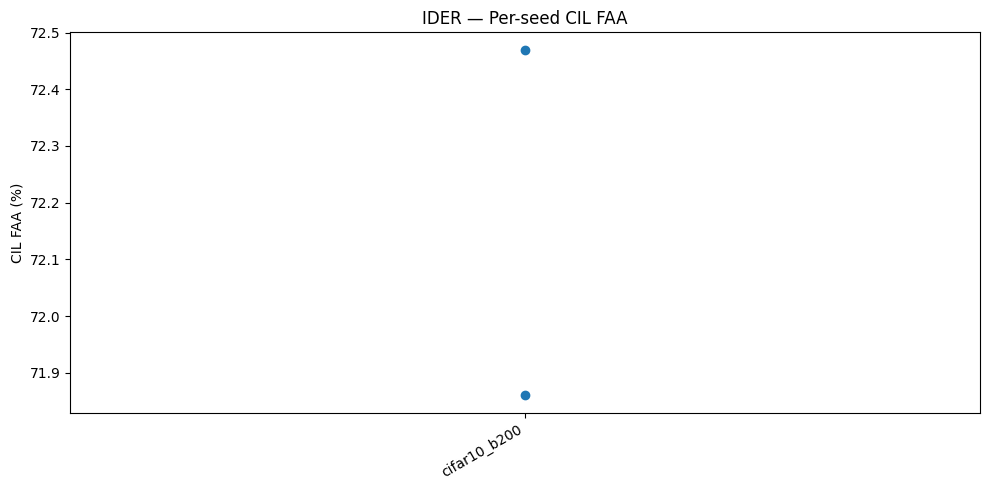

In [51]:
# Step 51 — Per-seed CIL scatter

plt.figure(figsize=(10, 5))
for exp_name, g in results.groupby("experiment"):
    x = [exp_name] * len(g)
    plt.scatter(x, g["CIL_FAA"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("CIL FAA (%)")
plt.title("IDER — Per-seed CIL FAA")
plt.tight_layout()
plt.savefig(OUT/"per_seed_cil.png", dpi=200, bbox_inches="tight")
plt.show()


In [52]:
# Step 52 — Load task snapshots

snapshot_rows = []
for p in sorted(OUT.glob("*/seed_*/task_snapshots.json")):
    exp = p.parts[-3]
    seed = int(p.parts[-2].split("_")[-1])
    payload = json.loads(p.read_text())
    snapshot_rows.append((exp, seed, payload))

print("Snapshot files:", len(snapshot_rows))


Snapshot files: 2


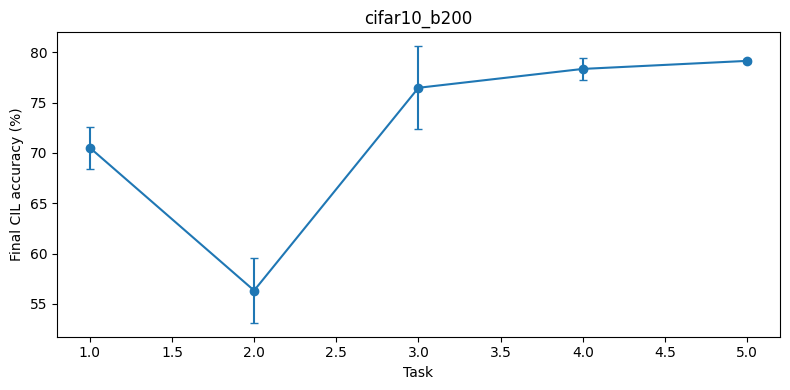

In [53]:
# Step 53 — Plot final per-task CIL accuracy for each experiment (seed mean)

for exp_name in ACTIVE_EXPERIMENTS:
    selected = [(seed, p) for exp, seed, p in snapshot_rows if exp == exp_name]
    if not selected:
        continue

    finals = np.array([p["cil_snapshots"][-1] for _, p in selected], dtype=float)
    mean = finals.mean(axis=0)
    std = finals.std(axis=0, ddof=1) if len(finals) > 1 else np.zeros_like(mean)

    x = np.arange(1, len(mean)+1)
    plt.figure(figsize=(8, 4))
    plt.errorbar(x, mean, yerr=std, fmt="o-", capsize=3)
    plt.xlabel("Task")
    plt.ylabel("Final CIL accuracy (%)")
    plt.title(exp_name)
    plt.tight_layout()
    plt.savefig(OUT/f"{exp_name}_final_task_accuracy.png", dpi=200, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_23/24045467.py:15: RuntimeWarning: Mean of empty slice
  mean_matrix = np.nanmean(cube, axis=0)


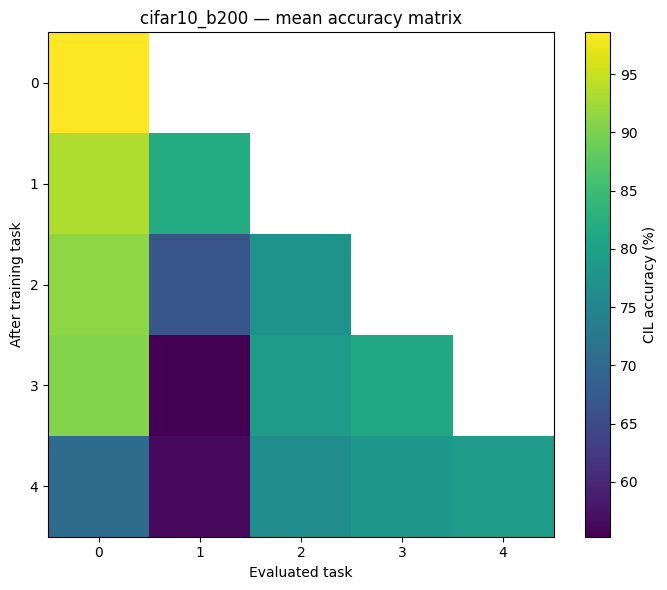

In [54]:
# Step 54 — Learning/forgetting trajectory heatmaps (mean across seeds)

for exp_name in ACTIVE_EXPERIMENTS:
    selected = [p["cil_snapshots"] for exp, seed, p in snapshot_rows if exp == exp_name]
    if not selected:
        continue

    T = max(len(x) for x in selected)
    cube = np.full((len(selected), T, T), np.nan)

    for si, snapshots in enumerate(selected):
        for t, row in enumerate(snapshots):
            cube[si, t, :len(row)] = row

    mean_matrix = np.nanmean(cube, axis=0)

    plt.figure(figsize=(7, 6))
    im = plt.imshow(mean_matrix, aspect="auto")
    plt.colorbar(im, label="CIL accuracy (%)")
    plt.xlabel("Evaluated task")
    plt.ylabel("After training task")
    plt.title(f"{exp_name} — mean accuracy matrix")
    plt.tight_layout()
    plt.savefig(OUT/f"{exp_name}_accuracy_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()


In [55]:
# Step 55 — Generate LaTeX result rows

latex_rows = []
for _, r in agg.iterrows():
    latex_rows.append(
        f"{r['experiment']} & "
        f"{r['CIL_mean']:.2f} $\\pm$ {r['CIL_std']:.2f} & "
        f"{r['TIL_mean']:.2f} $\\pm$ {r['TIL_std']:.2f} & "
        f"{r['FF_mean']:.2f} $\\pm$ {r['FF_std']:.2f} \\\\"
    )

latex_text = "\n".join(latex_rows)
print(latex_text)
(OUT/"latex_result_rows.txt").write_text(latex_text)


cifar10_b200 & 72.16 $\pm$ 0.43 & 95.81 $\pm$ 0.59 & 14.95 $\pm$ 0.46 \\


72

In [56]:
# Step 56 — Save environment versions

import pkgutil

env_info = {
    "python": sys.version,
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "cuda_runtime": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
    "repo_commit": commit,
}
(OUT/"environment.json").write_text(json.dumps(env_info, indent=2))
print(json.dumps(env_info, indent=2))


{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "torch": "2.10.0+cu128",
  "torchvision": "0.25.0+cu128",
  "cuda_runtime": "12.8",
  "gpu": "Tesla T4",
  "repo_commit": "18abadc8477c82fe384847493948acdc81004dc2"
}


In [57]:
# Step 57 — Check persistent checkpoint inventory

repo_checkpoints = checkpoint_candidates()
persistent_checkpoints = sorted(
    p for p in CHECKPOINT_OUT.rglob("*")
    if p.is_file() and (
        p.suffix.lower() in {".pth", ".pt", ".ckpt"}
        or p.name.lower().endswith(".pth.tar")
    )
)

print("Repository checkpoints currently present:", len(repo_checkpoints))
print("Persistent copied checkpoints:", len(persistent_checkpoints))

for p in persistent_checkpoints[:100]:
    print(p)


Repository checkpoints currently present: 57
Persistent copied checkpoints: 2
/kaggle/working/ider_reproduction/checkpoints/cifar10_b200/seed_0/experiments__seq-cifar10__buffer_200__ider_seed_0.pth
/kaggle/working/ider_reproduction/checkpoints/cifar10_b200/seed_1/experiments__seq-cifar10__buffer_200__ider_seed_1.pth


In [58]:
# Step 58 — Verify automatic persistent checkpoint storage

print("Automatic checkpoint copying is ENABLED.")
print("Destination:", CHECKPOINT_OUT)

run_manifests = sorted(CHECKPOINT_OUT.glob("*/seed_*/checkpoint_manifest.json"))
print("Checkpoint manifests:", len(run_manifests))

for p in run_manifests:
    try:
        d = json.loads(p.read_text(encoding="utf-8"))
        print(
            d["experiment"],
            "seed",
            d["seed"],
            "->",
            d["copied_checkpoint_count"],
            "checkpoint(s)"
        )
    except Exception as exc:
        print("Could not read:", p, exc)


Automatic checkpoint copying is ENABLED.
Destination: /kaggle/working/ider_reproduction/checkpoints
Checkpoint manifests: 2
cifar10_b200 seed 0 -> 1 checkpoint(s)
cifar10_b200 seed 1 -> 1 checkpoint(s)


In [59]:
# Step 59 — Validate expected run count

expected = len(ACTIVE_EXPERIMENTS) * len(SEEDS)
actual = len(results)

print("Expected runs:", expected)
print("Completed runs:", actual)

if actual != expected:
    print("WARNING: not all runs completed. Re-run Cell 41; completed jobs will be skipped.")
else:
    print("All runs completed.")


Expected runs: 30
Completed runs: 2


In [60]:
# Step 60 — Validate finite metrics

metric_cols = ["CIL_FAA", "TIL_FAA", "Final_Forgetting"]
finite_ok = np.isfinite(results[metric_cols].to_numpy()).all()
print("All metrics finite:", finite_ok)
if not finite_ok:
    raise RuntimeError("Non-finite metric detected.")


All metrics finite: True


In [61]:
# Step 61 — Save a compact final report

report_lines = [
    "IDER ICLR 2026 — Kaggle reproduction",
    f"Repository commit: {commit}",
    f"Completed runs: {len(results)}/{len(ACTIVE_EXPERIMENTS)*len(SEEDS)}",
    "Paper comparison: Table 1 FAA + Table 7 FF",
    "TIL FAA: extra diagnostic only (not a main paper-table metric)",
    "",
]

for _, r in agg.iterrows():
    report_lines += [
        r["experiment"],
        f"  CIL FAA: {r['CIL_mean']:.2f} ± {r['CIL_std']:.2f}",
        f"  FF:      {r['FF_mean']:.2f} ± {r['FF_std']:.2f}",
        f"  TIL FAA (extra): {r['TIL_mean']:.2f} ± {r['TIL_std']:.2f}",
        "",
    ]

report = "\n".join(report_lines)
print(report)
(OUT/"FINAL_REPORT.txt").write_text(report)


IDER ICLR 2026 — Kaggle reproduction
Repository commit: 18abadc8477c82fe384847493948acdc81004dc2
Completed runs: 2/30
Paper comparison: Table 1 FAA + Table 7 FF
TIL FAA: extra diagnostic only (not a main paper-table metric)

cifar10_b200
  CIL FAA: 72.16 ± 0.43
  FF:      14.95 ± 0.46
  TIL FAA (extra): 95.81 ± 0.59



318

In [62]:
# Step 62 — Package results and multi-session resume state

# Full portable resume bundle, including copied checkpoints.
build_resume_bundle()

# A separate results archive is also created.
results_archive = shutil.make_archive(
    str(ROOT/"IDER_ICLR2026_Kaggle_Results"),
    "zip",
    root_dir=OUT,
)

print("Results archive:", results_archive)
print("Resume bundle:", RESUME_BUNDLE)
print()
print("For another Kaggle session, preserve and attach:")
print(RESUME_BUNDLE)


Resume bundle updated: /kaggle/working/IDER_RESUME_BUNDLE.zip | completed 2/30
Results archive: /kaggle/working/IDER_ICLR2026_Kaggle_Results.zip
Resume bundle: /kaggle/working/IDER_RESUME_BUNDLE.zip

For another Kaggle session, preserve and attach:
/kaggle/working/IDER_RESUME_BUNDLE.zip
